# Dataset 1: Epileptic Seizure Recognition

# Import the Libraries

In [1]:
pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load the Data and Pre-process

In [1]:
import pandas as pd

# Read the CSV file into a DataFrame
df = pd.read_csv("/user/HS401/lm02027/Downloads/Epileptic Seizure Recognition.csv")

# Display the first few rows
print(df.head())

      Unnamed   X1   X2   X3   X4   X5   X6   X7   X8   X9  ...  X170  X171  \
0  X21.V1.791  135  190  229  223  192  125   55   -9  -33  ...   -17   -15   
1  X15.V1.924  386  382  356  331  320  315  307  272  244  ...   164   150   
2     X8.V1.1  -32  -39  -47  -37  -32  -36  -57  -73  -85  ...    57    64   
3   X16.V1.60 -105 -101  -96  -92  -89  -95 -102 -100  -87  ...   -82   -81   
4   X20.V1.54   -9  -65  -98 -102  -78  -48  -16    0  -21  ...     4     2   

   X172  X173  X174  X175  X176  X177  X178  y  
0   -31   -77  -103  -127  -116   -83   -51  4  
1   146   152   157   156   154   143   129  1  
2    48    19   -12   -30   -35   -35   -36  5  
3   -80   -77   -85   -77   -72   -69   -65  5  
4   -12   -32   -41   -65   -83   -89   -73  5  

[5 rows x 180 columns]


In [5]:
#Get the number of rows and columns
print(df.shape)

(11500, 180)


In [6]:
#List column names, data types, and non-null counts
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Columns: 180 entries, Unnamed to y
dtypes: int64(179), object(1)
memory usage: 15.8+ MB
None


In [7]:
#Compute basic statistics (mean, median, standard deviation, etc.) for numerical columns
print(df.describe())

                 X1            X2            X3            X4            X5  \
count  11500.000000  11500.000000  11500.000000  11500.000000  11500.000000   
mean     -11.581391    -10.911565    -10.187130     -9.143043     -8.009739   
std      165.626284    166.059609    163.524317    161.269041    160.998007   
min    -1839.000000  -1838.000000  -1835.000000  -1845.000000  -1791.000000   
25%      -54.000000    -55.000000    -54.000000    -54.000000    -54.000000   
50%       -8.000000     -8.000000     -7.000000     -8.000000     -8.000000   
75%       34.000000     35.000000     36.000000     36.000000     35.000000   
max     1726.000000   1713.000000   1697.000000   1612.000000   1518.000000   

                 X6            X7           X8           X9           X10  \
count  11500.000000  11500.000000  11500.00000  11500.00000  11500.000000   
mean      -7.003478     -6.502087     -6.68713     -6.55800     -6.168435   
std      161.328725    161.467837    162.11912    162.033

In [8]:
#Identify missing values across columns
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

Series([], dtype: int64)


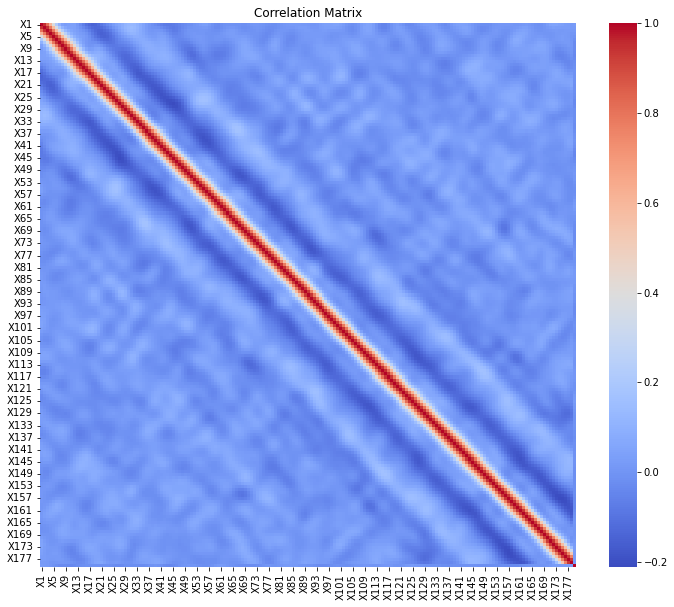

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Remove non-numeric columns
df_numeric = df.drop(columns=['Unnamed'])

# Compute and visualize the correlation matrix
plt.figure(figsize=(12, 10))
correlation_matrix = df_numeric.corr()
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False)
plt.title('Correlation Matrix')
plt.show()

In [10]:
# Select only numeric columns for the features
numeric_data = df.select_dtypes(include=['number'])
print(numeric_data.iloc[0, :-1])  # Check the first row's data (excluding the target column)

X1      135
X2      190
X3      229
X4      223
X5      192
       ... 
X174   -103
X175   -127
X176   -116
X177    -83
X178    -51
Name: 0, Length: 178, dtype: int64


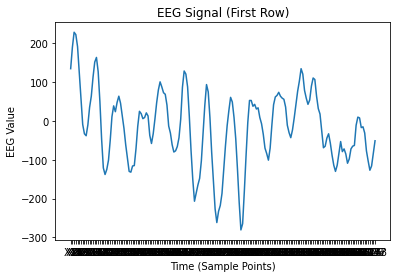

In [11]:
plt.plot(numeric_data.iloc[0, :-1])  # Plot the first row's EEG signal
plt.title("EEG Signal (First Row)")
plt.xlabel("Time (Sample Points)")
plt.ylabel("EEG Value")
plt.show()

In [12]:
#Standardizing features (X1 to X178) ensures that all variables are on the same scale
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = df.iloc[:, 1:-1] # Extract feature columns
X_scaled = scaler.fit_transform(X)

In [13]:
df.head()

,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


In [14]:
# Check class distribution
#Analyze the distribution of the target variable (y) to check for imbalances
class_distribution = df.iloc[:, -1].value_counts()
print(class_distribution)

4    2300
1    2300
5    2300
2    2300
3    2300
Name: y, dtype: int64


In [2]:
# Modify the target variable in the DataFrame 
df.iloc[:, -1] = df.iloc[:, -1].apply(lambda label: 1 if label == 1 else 0)

# Verify the changes
print(df.iloc[:, -1].value_counts())

0    9200
1    2300
Name: y, dtype: int64


In [3]:
df.head()

,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,0
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,0
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,0
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,0


/tmp/ipykernel_51741/2197122450.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_distribution.index, y=class_distribution.values, palette="viridis")


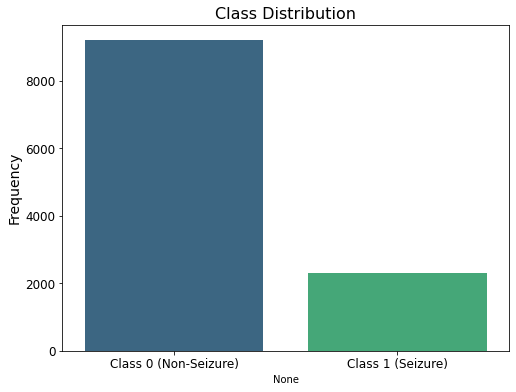

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# target variable is 'y' in the DataFrame
class_distribution = df['y'].value_counts()  

# Plot the class distribution
plt.figure(figsize=(8, 6))
sns.barplot(x=class_distribution.index, y=class_distribution.values, palette="viridis")
plt.title("Class Distribution", fontsize=16)
plt.ylabel("Frequency", fontsize=14)
plt.xticks(ticks=[0, 1], labels=["Class 0 (Non-Seizure)", "Class 1 (Seizure)"], fontsize=12)
plt.yticks(fontsize=12)
plt.show()

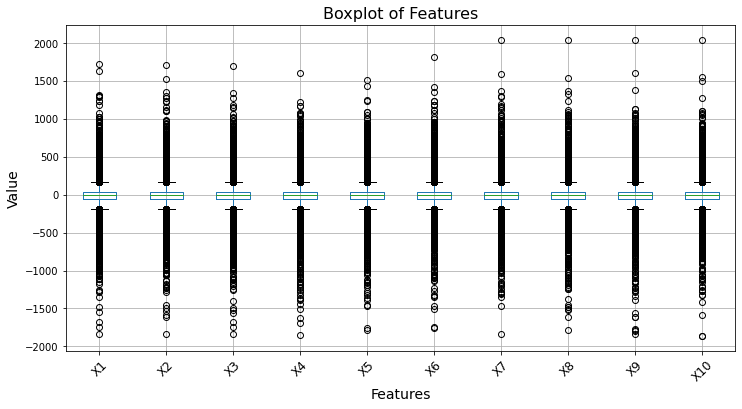

In [18]:
import matplotlib.pyplot as plt

# Plot boxplots for a subset of features (first 10 features)
plt.figure(figsize=(12, 6))
df.iloc[:, 1:11].boxplot()
plt.title("Boxplot of Features", fontsize=16)
plt.xlabel("Features", fontsize=14)
plt.ylabel("Value", fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.show()

/tmp/ipykernel_51741/2976604901.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='y', y='X1', data=df, palette="muted")


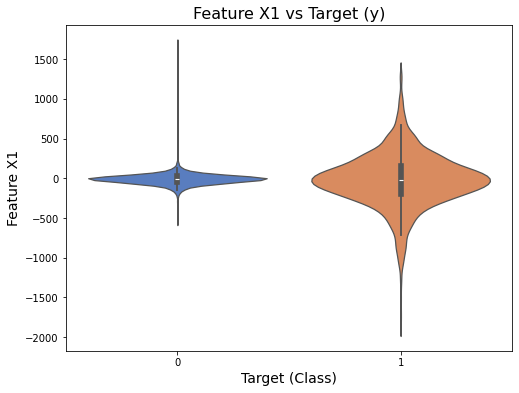

In [19]:
import seaborn as sns

# Feature-target relationship
# Violin plot for the first feature ('X1') vs target ('y')
plt.figure(figsize=(8, 6))
sns.violinplot(x='y', y='X1', data=df, palette="muted") 
plt.title("Feature X1 vs Target (y)", fontsize=16)
plt.xlabel("Target (Class)", fontsize=14)
plt.ylabel("Feature X1", fontsize=14)
plt.show()

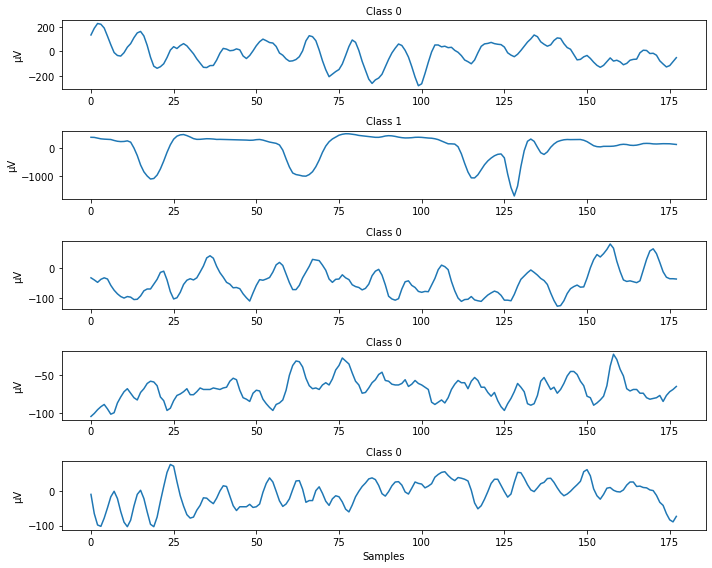

In [20]:
import matplotlib.pyplot as plt

# Select a subset of rows for plotting (first 5 rows) and exclude the target column 'y'
rows_to_plot = df.iloc[:5, 1:-1]  

# Plot the signals
plt.figure(figsize=(10, 8))  # Adjust size to accommodate subplots
for i, row in enumerate(rows_to_plot.values):
    plt.subplot(5, 1, i + 1)  # Create 5 subplots 
    plt.plot(row)
    plt.title(f"Class {df.iloc[i, -1]}", fontsize=10)  # Title shows the class from the target column 'y'
    plt.ylabel("µV")  # Label for voltage
    if i == 4:  
        plt.xlabel("Samples")

# Adjust layout for better visualization
plt.tight_layout()
plt.show()

# MLP implementation using sklearn

Accuracy: 0.9800
Precision: 0.9816
Recall: 0.9183
F1-Score: 0.9489
Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1835
           1       0.98      0.92      0.95       465

    accuracy                           0.98      2300
   macro avg       0.98      0.96      0.97      2300
weighted avg       0.98      0.98      0.98      2300

Confusion Matrix:
[[1827    8]
 [  38  427]]


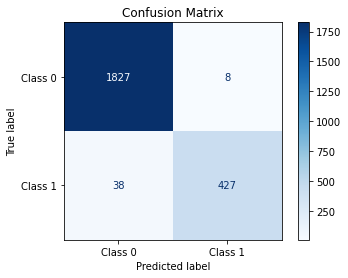

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report,precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# Prepare the data
# Separate features (X) and target (y)
X = df.iloc[:, 1:-1].values  # All features (excluding first column and target)
y = df.iloc[:, -1].values    # Target variable

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the input features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build and train the MLP model using MLPClassifier
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),  # Three hidden layers with specified neurons
    activation='relu',                 # Activation function
    solver='adam',                     # Optimizer
    max_iter=200,                      # Number of iterations
    random_state=42
)

# Train the model
mlp.fit(X_train, y_train)

# Evaluate the model
y_pred = mlp.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
# Calculate precision, recall, and F1 score
precision = precision_score(y_test, y_pred, average='binary')  # Use 'binary' for binary classification
recall = recall_score(y_test, y_pred, average='binary')
f1 = f1_score(y_test, y_pred, average='binary')

# Print individual metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Generate predictions
y_pred = (mlp.predict(X_test) > 0.5).astype("int32")  # Threshold for binary classification

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

## ROC Curve for MLP with different hidden layers

/user/HS401/lm02027/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/user/HS401/lm02027/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Baseline (random guess): ROC AUC=0.500
MLP 1 (hidden layer sizes=5): ROC AUC=0.868
MLP 2 (hidden layer sizes=10): ROC AUC=0.967
MLP 3 (hidden layer sizes=(128, 64, 32)): ROC AUC=0.993


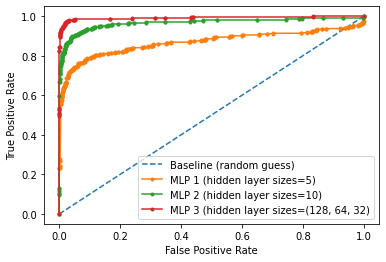

In [23]:
# Code referred from week3 lab
# roc curve and auc
from sklearn.datasets import make_classification
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
from sklearn.neural_network import MLPClassifier

# generate a random prediction (majority class)
ns_probs = [0 for _ in range(len(y_test))]
# fit first model(MLP 1)
clf1 = MLPClassifier(activation='relu',
        solver='adam',
        max_iter=100,
        random_state=42,
        hidden_layer_sizes=(5,))
clf1.fit(X_train, y_train)
# fit second model(MLP 2)
clf2 = MLPClassifier(activation='relu',
        solver='adam',
        max_iter=200,
        random_state=42,
        hidden_layer_sizes=(10,))
clf2.fit(X_train, y_train)
# fit third model(MLP 2)
clf3 = MLPClassifier(activation='relu',
        solver='adam',
        max_iter=200,
        random_state=42,
        hidden_layer_sizes=((128, 64, 32)))
clf3.fit(X_train, y_train)

# predict probabilities for different models
lr_probs1 = clf1.predict_proba(X_test)
lr_probs2 = clf2.predict_proba(X_test)
lr_probs3 = clf3.predict_proba(X_test)

# keep probabilities for the positive outcome only
lr_probs1 = lr_probs1[:, 1]
lr_probs2 = lr_probs2[:, 1]
lr_probs3 = lr_probs3[:, 1]

# calculate accuracy score for random prediction model
ns_auc = roc_auc_score(y_test, ns_probs)

# calculate accuracy score different MLP models
lr_auc1 = roc_auc_score(y_test, lr_probs1)
lr_auc2 = roc_auc_score(y_test, lr_probs2)
lr_auc3 = roc_auc_score(y_test, lr_probs3)

# summarize scores
print('Baseline (random guess): ROC AUC=%.3f' % (ns_auc))
print('MLP 1 (hidden layer sizes=5): ROC AUC=%.3f' % (lr_auc1))
print('MLP 2 (hidden layer sizes=10): ROC AUC=%.3f' % (lr_auc2))
print('MLP 3 (hidden layer sizes=(128, 64, 32)): ROC AUC=%.3f' % (lr_auc3))

# calculate roc curves
ns_fpr, ns_tpr, _ = roc_curve(y_test, ns_probs)
lr_fpr1, lr_tpr1, _ = roc_curve(y_test, lr_probs1)
lr_fpr2, lr_tpr2, _ = roc_curve(y_test, lr_probs2)
lr_fpr3, lr_tpr3, _ = roc_curve(y_test, lr_probs3)

# plot the roc curve for the model
pyplot.plot(ns_fpr, ns_tpr, linestyle='--', label='Baseline (random guess)')
pyplot.plot(lr_fpr1, lr_tpr1, marker='.', label='MLP 1 (hidden layer sizes=5)')
pyplot.plot(lr_fpr2, lr_tpr2, marker='.', label='MLP 2 (hidden layer sizes=10)')
pyplot.plot(lr_fpr3, lr_tpr3, marker='.', label='MLP 3 (hidden layer sizes=(128, 64, 32)')
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
# show the plot
pyplot.show()

# MLP implementation using keras and Tensorflow

In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Prepare the data
# Separate features (X) and target (y)
X = df.iloc[:, 1:-1].values  # All features (excluding first column and target)
y = df.iloc[:, -1].values    # Target variable

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the input features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build the MLP model
model = Sequential([
    Input(shape=(X_train.shape[1],)),  # Input layer
    Dense(128, activation='relu'),    # First hidden layer
    Dense(64, activation='relu'),     # Second hidden layer
    Dense(32, activation='relu'),     # Third hidden layer
    Dense(1, activation='sigmoid')    # Output layer
])

model.summary()

W0000 00:00:1735871911.034332   51741 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        22,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,281 (130.00 KB)

 Trainable params: 33,281 (130.00 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8796 - loss: 0.4307 - val_accuracy: 0.9549 - val_loss: 0.1435
Epoch 2/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9715 - loss: 0.1048 - val_accuracy: 0.9630 - val_loss: 0.1069
Epoch 3/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9788 - loss: 0.0761 - val_accuracy: 0.9734 - val_loss: 0.0903
Epoch 4/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9847 - loss: 0.0470 - val_accuracy: 0.9674 - val_loss: 0.1174
Epoch 5/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9872 - loss: 0.0404 - val_accuracy: 0.9658 - val_loss: 0.1065
Epoch 6/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9928 - loss: 0.0265 - val_accuracy: 0.9630 - val_loss: 0.1423
Epoch 7/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9919 - loss: 0.0284 - val_accuracy: 0.9658 - val_loss: 0.1407
Epoch 8/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9890 - loss: 0.0414 - val_accuracy: 0.

In [26]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Predict on the test set
y_pred = (model.predict(X_test) > 0.5).astype("int32")  # Threshold to convert probabilities to binary values

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Class 0", "Class 1"]))

# Calculate individual metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print individual metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Classification Report:
              precision    recall  f1-score   support

     Class 0       0.97      0.99      0.98      1835
     Class 1       0.97      0.89      0.93       465

    accuracy                           0.97      2300
   macro avg       0.97      0.94      0.96      2300
weighted avg       0.97      0.97      0.97      2300

Accuracy: 0.9730
Precision: 0.9697
Recall: 0.8946
F1-Score: 0.9306


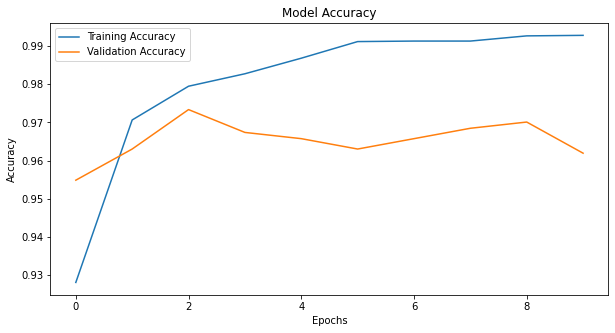

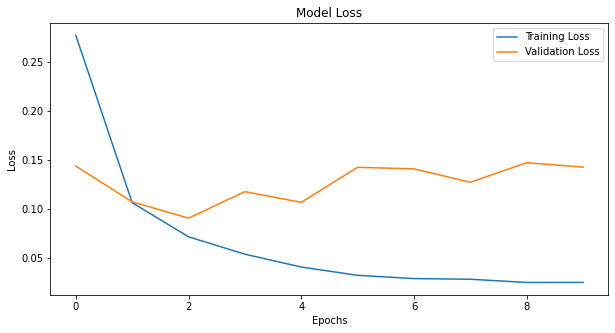

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 727us/step
Confusion Matrix:
[[1822   13]
 [  49  416]]


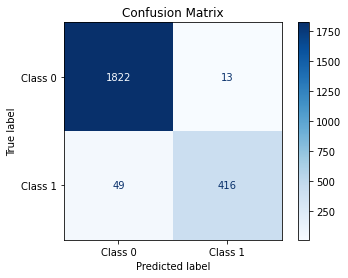

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate predictions
y_pred = (model.predict(X_test) > 0.5).astype("int32")  # Threshold for binary classification

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

# MLP after Hyper-Parameter Tuning

In [32]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout

# Build the model
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stop, reduce_lr])

Epoch 1/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8966 - loss: 0.2547 - val_accuracy: 0.9484 - val_loss: 0.1175 - learning_rate: 0.0010
Epoch 2/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9514 - loss: 0.1153 - val_accuracy: 0.9630 - val_loss: 0.0867 - learning_rate: 0.0010
Epoch 3/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9621 - loss: 0.0961 - val_accuracy: 0.9636 - val_loss: 0.0996 - learning_rate: 0.0010
Epoch 4/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9640 - loss: 0.0929 - val_accuracy: 0.9630 - val_loss: 0.0922 - learning_rate: 0.0010
Epoch 5/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9712 - loss: 0.0726 - val_accuracy: 0.9587 - val_loss: 0.0983 - learning_rate: 0.0010
Epoch 6/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9726 - loss: 0.0687 - val_accuracy: 0.9668 - val_loss: 0.0863 - learning_rate: 5.0000e-04
Epoch 7/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9781 - loss: 0.058

In [33]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Predict on the test set
y_pred = (model.predict(X_test) > 0.5).astype("int32")  # Threshold to convert probabilities to binary values

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Class 0", "Class 1"]))

# Calculate individual metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print individual metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Classification Report:
              precision    recall  f1-score   support

     Class 0       0.98      0.99      0.99      1835
     Class 1       0.97      0.94      0.96       465

    accuracy                           0.98      2300
   macro avg       0.98      0.97      0.97      2300
weighted avg       0.98      0.98      0.98      2300

Accuracy: 0.9822
Precision: 0.9711
Recall: 0.9398
F1-Score: 0.9552


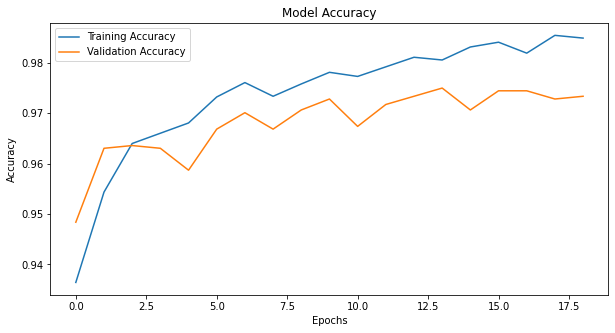

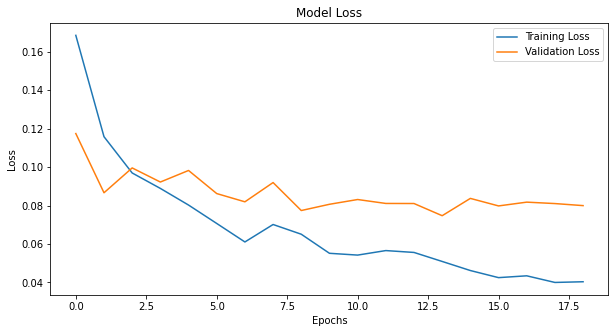

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 802us/step
Confusion Matrix:
[[1822   13]
 [  28  437]]


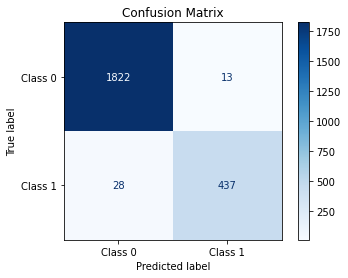

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate predictions
y_pred = (model.predict(X_test) > 0.5).astype("int32")  # Threshold for binary classification

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

# Dataset 2: Loan Approval Classification Dataset

# Load the pre-processed Data

In [6]:
import pandas as pd

# Read the CSV file into a DataFrame
df = pd.read_csv("/user/HS401/lm02027/Downloads/loan_data_preprocessed.csv")

# Display the first few rows
print(df.head())

   person_age  person_education  person_income  person_emp_exp  loan_amnt  \
0        22.0                 4      -0.104090               0   4.024953   
1        21.0                 3      -0.846005               0  -1.359209   
2        25.0                 3      -0.844065               3  -0.646600   
3        23.0                 1      -0.007039               0   4.024953   
4        24.0                 4      -0.176371               1   4.024953   

   loan_int_rate  loan_percent_income  cb_person_cred_hist_length  \
0          16.02                 0.49                         3.0   
1          11.14                 0.08                         2.0   
2          12.87                 0.44                         3.0   
3          15.23                 0.44                         2.0   
4          14.27                 0.53                         4.0   

   credit_score  loan_status  person_gender_male  person_home_ownership_OTHER  \
0     -1.419814            1             

In [37]:
df.head()

,person_age,person_education,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status,person_gender_male,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_Yes
0,22.0,4,-0.104090,0,4.024953,16.02,0.49,3.0,-1.419814,1,False,False,False,True,False,False,False,True,False,False
1,21.0,3,-0.846005,0,-1.359209,11.14,0.08,2.0,-2.549975,0,False,False,True,False,True,False,False,False,False,True
2,25.0,3,-0.844065,3,-0.646600,12.87,0.44,3.0,0.047412,1,False,False,False,False,False,False,True,False,False,False
3,23.0,1,-0.007039,0,4.024953,15.23,0.44,2.0,0.840507,1,False,False,False,True,False,False,True,False,False,False
4,24.0,4,-0.176371,1,4.024953,14.27,0.53,4.0,-0.924130,1,True,False,False,True,False,False,True,False,False,False


In [38]:
# Separate features (X) and target (y)
X = df.drop('loan_status', axis=1)  # 'loan_status' is the target column
y = df['loan_status']
from sklearn.model_selection import train_test_split
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (36000, 19)
Test set size: (9000, 19)


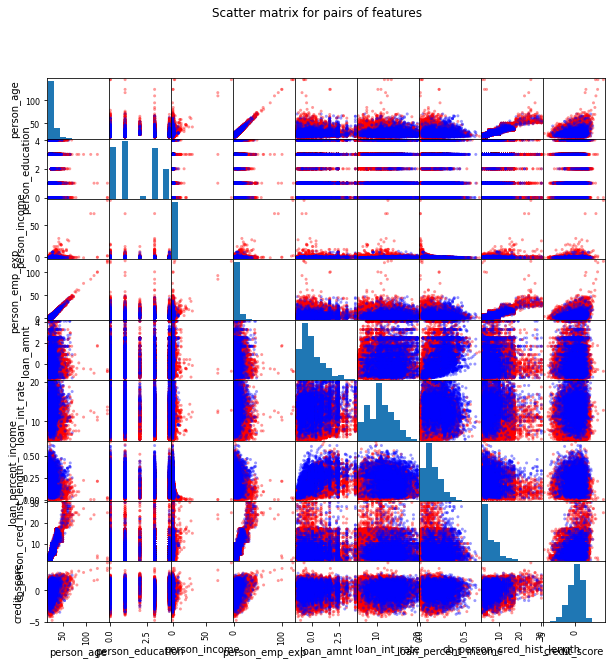

In [39]:
# Referred from week2 lab exercise
# Create a color dictionary for 'loan_status'
color_dic = {0: 'red', 1: 'blue'}

# Extract the target column and map it to colors
target_list = list(df['loan_status']) 
colors = list(map(lambda x: color_dic.get(x), target_list))

# Select numeric columns for scatter matrix
features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
features.remove('loan_status')  # Exclude the target column

# Plotting the scatter matrix
sm = pd.plotting.scatter_matrix(df[features], c=colors, alpha=0.4, figsize=(10, 10))

# Add a title to the plot
plt.suptitle("Scatter matrix for pairs of features")
plt.show()

# MLP implementation using sklearn

/user/HS401/lm02027/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.9102
Precision: 0.8277
Recall: 0.7552
F1-Score: 0.7898
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      6990
           1       0.83      0.76      0.79      2010

    accuracy                           0.91      9000
   macro avg       0.88      0.86      0.87      9000
weighted avg       0.91      0.91      0.91      9000

Confusion Matrix:
[[6674  316]
 [ 492 1518]]


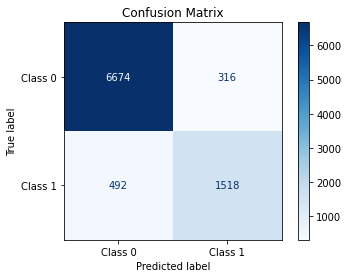

In [40]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report,precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# Build and train the MLP model using MLPClassifier
mlp2= MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),  # Three hidden layers with specified neurons
    activation='relu',                 # Activation function
    solver='adam',                     # Optimizer
    max_iter=200,                      # Number of iterations
    random_state=42
)

# Train the model
mlp2.fit(X_train, y_train)

# Evaluate the model
y_pred = mlp2.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='binary')  # Use 'binary' for binary classification
recall = recall_score(y_test, y_pred, average='binary')
f1 = f1_score(y_test, y_pred, average='binary')

# Print individual metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Generate predictions
y_pred = (mlp2.predict(X_test) > 0.5).astype("int32")  # Threshold for binary classification

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

/user/HS401/lm02027/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/user/HS401/lm02027/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Baseline (random guess): ROC AUC=0.500
MLP 1 (hidden layer sizes=5): ROC AUC=0.959
MLP 2 (hidden layer sizes=10): ROC AUC=0.952
MLP 3 (hidden layer sizes=(128, 64, 32)): ROC AUC=0.962


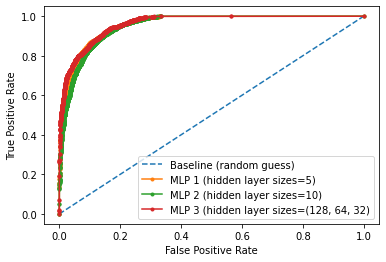

In [41]:
# Referred code from week3 lab
# roc curve and auc
from sklearn.datasets import make_classification
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
from sklearn.neural_network import MLPClassifier

# generate a random prediction (majority class)
ns_probs = [0 for _ in range(len(y_test))]
# fit first model(MLP 1)
clf1 = MLPClassifier(activation='relu',
        solver='adam',
        max_iter=100,
        random_state=42,
        hidden_layer_sizes=(5,))
clf1.fit(X_train, y_train)
# fit second model(MLP 2)
clf2 = MLPClassifier(activation='relu',
        solver='adam',
        max_iter=200,
        random_state=42,
        hidden_layer_sizes=(10,))
clf2.fit(X_train, y_train)
# fit third model(MLP 2)
clf3 = MLPClassifier(activation='relu',
        solver='adam',
        max_iter=200,
        random_state=42,
        hidden_layer_sizes=((128, 64, 32)))
clf3.fit(X_train, y_train)

# predict probabilities for different models
lr_probs1 = clf1.predict_proba(X_test)
lr_probs2 = clf2.predict_proba(X_test)
lr_probs3 = clf3.predict_proba(X_test)

# keep probabilities for the positive outcome only
lr_probs1 = lr_probs1[:, 1]
lr_probs2 = lr_probs2[:, 1]
lr_probs3 = lr_probs3[:, 1]

# calculate accuracy score for random prediction model
ns_auc = roc_auc_score(y_test, ns_probs)

# calculate accuracy score different MLP models
lr_auc1 = roc_auc_score(y_test, lr_probs1)
lr_auc2 = roc_auc_score(y_test, lr_probs2)
lr_auc3 = roc_auc_score(y_test, lr_probs3)

# summarize scores
print('Baseline (random guess): ROC AUC=%.3f' % (ns_auc))
print('MLP 1 (hidden layer sizes=5): ROC AUC=%.3f' % (lr_auc1))
print('MLP 2 (hidden layer sizes=10): ROC AUC=%.3f' % (lr_auc2))
print('MLP 3 (hidden layer sizes=(128, 64, 32)): ROC AUC=%.3f' % (lr_auc3))

# calculate roc curves
ns_fpr, ns_tpr, _ = roc_curve(y_test, ns_probs)
lr_fpr1, lr_tpr1, _ = roc_curve(y_test, lr_probs1)
lr_fpr2, lr_tpr2, _ = roc_curve(y_test, lr_probs2)
lr_fpr3, lr_tpr3, _ = roc_curve(y_test, lr_probs3)

# plot the roc curve for the model
pyplot.plot(ns_fpr, ns_tpr, linestyle='--', label='Baseline (random guess)')
pyplot.plot(lr_fpr1, lr_tpr1, marker='.', label='MLP 1 (hidden layer sizes=5)')
pyplot.plot(lr_fpr2, lr_tpr2, marker='.', label='MLP 2 (hidden layer sizes=10)')
pyplot.plot(lr_fpr3, lr_tpr3, marker='.', label='MLP 3 (hidden layer sizes=(128, 64, 32)')
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
# show the plot
pyplot.show()

# MLP implementation using keras and Tensorflow

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam


# Build the MLP model
model = Sequential([
    Input(shape=(X_train.shape[1],)),  # Input layer
    Dense(128, activation='relu'),    # First hidden layer
    Dense(64, activation='relu'),     # Second hidden layer
    Dense(32, activation='relu'),     # Third hidden layer
    Dense(1, activation='sigmoid')    # Output layer
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

Epoch 1/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8424 - loss: 0.3461 - val_accuracy: 0.8554 - val_loss: 0.3027
Epoch 2/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8841 - loss: 0.2484 - val_accuracy: 0.8976 - val_loss: 0.2211
Epoch 3/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8916 - loss: 0.2293 - val_accuracy: 0.9003 - val_loss: 0.2096
Epoch 4/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8999 - loss: 0.2173 - val_accuracy: 0.9021 - val_loss: 0.2135
Epoch 5/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8984 - loss: 0.2159 - val_accuracy: 0.8793 - val_loss: 0.2496
Epoch 6/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8990 - loss: 0.2151 - val_accuracy: 0.9076 - val_loss: 0.2154
Epoch 7/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9024 - loss: 0.2074 - val_accuracy: 0.9043 - val_loss: 0.2010
Epoch 8/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9060 - loss: 0.2052 - val_accuracy: 0.

In [44]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Predict on the test set
y_pred = (model.predict(X_test) > 0.5).astype("int32")  # Threshold to convert probabilities to binary values

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Class 0", "Class 1"]))

# Calculate individual metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print individual metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 626us/step
Classification Report:
              precision    recall  f1-score   support

     Class 0       0.93      0.96      0.94      6990
     Class 1       0.84      0.76      0.80      2010

    accuracy                           0.91      9000
   macro avg       0.89      0.86      0.87      9000
weighted avg       0.91      0.91      0.91      9000

Accuracy: 0.9131
Precision: 0.8381
Recall: 0.7572
F1-Score: 0.7956


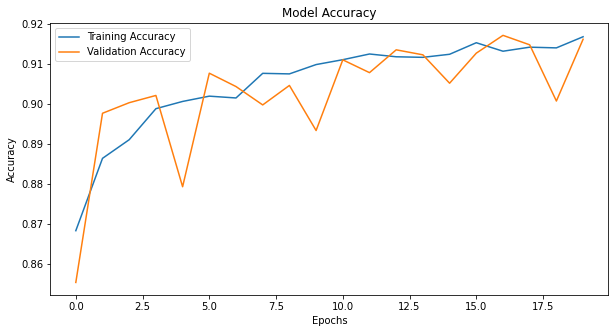

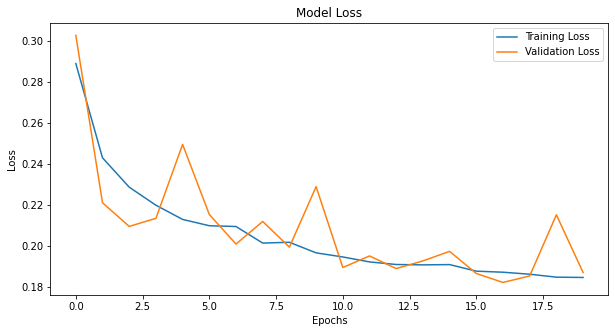

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 549us/step
Confusion Matrix:
[[6696  294]
 [ 488 1522]]


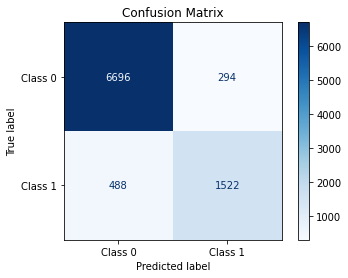

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate predictions
y_pred = (model.predict(X_test) > 0.5).astype("int32")  # Threshold for binary classification

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

## Cross-Validation implementation

In [47]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt

# Initialize StratifiedKFold
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_no = 1
results = []

# Cross-validation loop
for train_idx, val_idx in kfold.split(X_train, y_train):
    # Split into train and validation sets for this fold
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # Standardize the data
    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold)
    X_val_fold = scaler.transform(X_val_fold)
    
    # Build the model
    model = Sequential([
        Input(shape=(X_train_fold.shape[1],)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    
    # Train the model
    history = model.fit(X_train_fold, y_train_fold, validation_data=(X_val_fold, y_val_fold),
                        epochs=10, batch_size=32, verbose=0)
    
    # Evaluate the model
    scores = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    print(f"Fold {fold_no} - Loss: {scores[0]:.4f}, Accuracy: {scores[1]:.4f}")
    results.append(scores[1])
    fold_no += 1

# Cross-validation results
mean_accuracy = np.mean(results)
std_accuracy = np.std(results)
print(f"Mean Accuracy: {mean_accuracy:.4f}, Standard Deviation: {std_accuracy:.4f}")

Fold 1 - Loss: 0.1875, Accuracy: 0.9150
Fold 2 - Loss: 0.1903, Accuracy: 0.9149
Fold 3 - Loss: 0.1770, Accuracy: 0.9210
Fold 4 - Loss: 0.1861, Accuracy: 0.9157
Fold 5 - Loss: 0.1815, Accuracy: 0.9181
Mean Accuracy: 0.9169, Standard Deviation: 0.0023


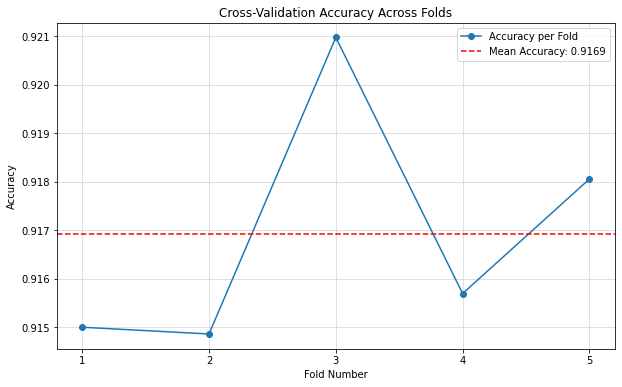

In [48]:
# Plot Cross-Validation Results
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(results) + 1), results, marker='o', linestyle='-', label="Accuracy per Fold")
plt.axhline(y=mean_accuracy, color='r', linestyle='--', label=f"Mean Accuracy: {mean_accuracy:.4f}")
plt.title("Cross-Validation Accuracy Across Folds")
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.xticks(range(1, len(results) + 1))
plt.legend()
plt.grid(alpha=0.5)
plt.show()

# MLP after Hyper-Parameter Tuning

In [49]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stop, reduce_lr])

Epoch 1/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8277 - loss: 0.3694 - val_accuracy: 0.8825 - val_loss: 0.2439 - learning_rate: 0.0010
Epoch 2/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8852 - loss: 0.2470 - val_accuracy: 0.8792 - val_loss: 0.2467 - learning_rate: 0.0010
Epoch 3/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8902 - loss: 0.2336 - val_accuracy: 0.9060 - val_loss: 0.2021 - learning_rate: 0.0010
Epoch 4/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8941 - loss: 0.2301 - val_accuracy: 0.9135 - val_loss: 0.1998 - learning_rate: 0.0010
Epoch 5/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9029 - loss: 0.2174 - val_accuracy: 0.8476 - val_loss: 0.3544 - learning_rate: 0.0010
Epoch 6/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9025 - loss: 0.2141 - val_accuracy: 0.9143 - val_loss: 0.1950 - learning_rate: 0.0010
Epoch 7/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9012 - loss: 0.2144 - 

In [50]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Predict on the test set
y_pred = (model.predict(X_test) > 0.5).astype("int32")  # Threshold to convert probabilities to binary values

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Class 0", "Class 1"]))

# Calculate individual metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print individual metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 717us/step
Classification Report:
              precision    recall  f1-score   support

     Class 0       0.93      0.97      0.95      6990
     Class 1       0.86      0.74      0.80      2010

    accuracy                           0.92      9000
   macro avg       0.90      0.85      0.87      9000
weighted avg       0.91      0.92      0.91      9000

Accuracy: 0.9162
Precision: 0.8630
Recall: 0.7428
F1-Score: 0.7984


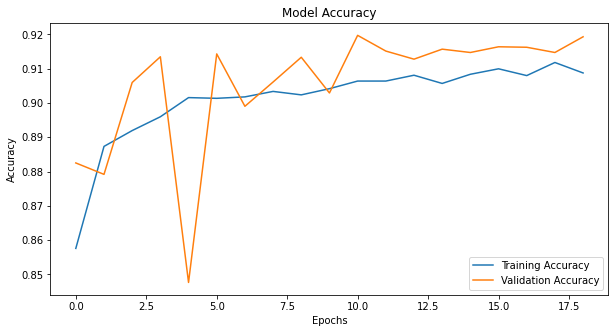

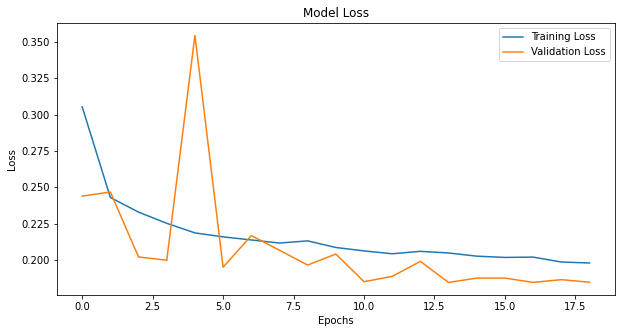

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 613us/step
Confusion Matrix:
[[6753  237]
 [ 517 1493]]


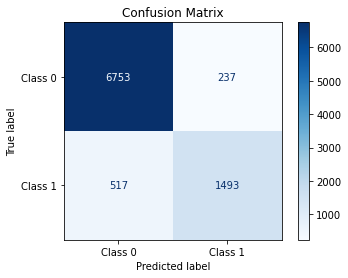

In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate predictions
y_pred = (model.predict(X_test) > 0.5).astype("int32")  # Threshold for binary classification

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

# Dataset 3: Carcinogenesis Relational Dataset

# Import the Libraries

In [53]:
!pip3 install janus-swi

Defaulting to user installation because normal site-packages is not writeable


In [54]:
!pip3 install PyILP

Defaulting to user installation because normal site-packages is not writeable


In [55]:
pip install pyswip

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


# Load prolog files and implement Aleph

In [1]:
import sys
import os
from contextlib import redirect_stdout, redirect_stderr
from pyswip import Prolog
import warnings
warnings.filterwarnings('ignore')

def extract_examples(exs_file):
    """
    Extract positive and negative examples from exs.pl.
    """
    pos_examples = []
    neg_examples = []

    with open(exs_file, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith("pos"):
                pos_examples.append(line[4:-2])  # Remove "pos(" and ")"
            elif line.startswith("neg"):
                neg_examples.append(line[4:-2])  # Remove "neg(" and ")"

    return pos_examples, neg_examples

def induce_hypotheses(input_file):
    """
    Use pyswip to consult input.pl and induce hypotheses using Aleph.
    """
    try:
        prolog = Prolog()

        # Redirect stdout and stderr to suppress Prolog output
        with open(os.devnull, 'w') as devnull, redirect_stdout(devnull), redirect_stderr(devnull):
            prolog.consult(input_file)
            result = list(prolog.query("induce(H)"))

        if result:
            hypotheses = result[0]['H']
            return hypotheses, prolog
        else:
            return None, prolog

    except Exception as e:
        print(f"An error occurred: {e}")
        return None, None

def evaluate_hypotheses(prolog, test_pos, test_neg):
    """
    Evaluate the induced hypotheses on the test set and calculate metrics.
    """
    tp = fp = tn = fn = 0

    for example in test_pos:
        result = list(prolog.query(example))
        if result:
            tp += 1  # Correctly classified as positive
        else:
            fn += 1  # Missed positive

    for example in test_neg:
        result = list(prolog.query(example))
        if result:
            fp += 1  # Incorrectly classified as positive
        else:
            tn += 1  # Correctly classified as negative

    # Calculate metrics
    accuracy = (tp + tn) / (tp + fp + tn + fn) if (tp + fp + tn + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    metrics = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score
    }

    confusion_matrix = {
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn
    }

    return metrics, confusion_matrix

# Hypothesis for input files

- Input 3: Limited to atomic-level data. - Input 2: Adds structural information (bonds).
- Input1: Further includes constraints, providing the richest set of background knowledg.


## Input 1: Contains atoms,bonds and other constraints

In [3]:
import sys
import os
from contextlib import redirect_stdout, redirect_stderr
from pyswip import Prolog
import warnings
warnings.filterwarnings('ignore')

if __name__ == "__main__":
    # File paths
    base_path = "/user/HS401/lm02027/Downloads/carcinogenesis"
    input_file = f"{base_path}/input.pl"
    exs_file = f"{base_path}/exs.pl"

    # Extract examples from exs.pl
    test_pos, test_neg = extract_examples(exs_file)

    # Induce hypotheses
    hypotheses, prolog = induce_hypotheses(input_file)

    # Restore stdout and stderr after Prolog calls
    if hypotheses:
        print("Induced Hypotheses:")
        for hypothesis in hypotheses:
            print(hypothesis)

        # Evaluate hypotheses
        metrics, confusion_matrix = evaluate_hypotheses(prolog, test_pos, test_neg)
        print("\nEvaluation Metrics:")
        for metric, value in metrics.items():
            print(f"{metric.capitalize()}: {value:.2f}")

        print("\nConfusion Matrix:")
        print(f"TP: {confusion_matrix['TP']}, FP: {confusion_matrix['FP']}")
        print(f"TN: {confusion_matrix['TN']}, FN: {confusion_matrix['FN']}")
    else:
        print("No hypotheses were induced.")

Induced Hypotheses:
:-(active(_850), ,(atm(_850, _862, c, 10, _868), ,(eq(_868, -0.003), ames(_850))))
active(d139)
active(d136)
:-(active(_1136), ,(atm(_1136, _1148, c, 10, _1154), eq(_1154, -0.121)))
active(d198)
active(d277)
:-(active(_1412), ,(atm(_1412, _1424, h, 3, _1430), ,(eq(_1430, 0.092), ames(_1412))))
:-(active(_1546), ,(ind(_1546, amino, _1560), ,(ind(_1546, di10, _1560), has_property(_1546, salmonella_n, n))))
active(d98)
active(d54)
active(d17)
:-(active(_1904), ,(atm(_1904, _1916, c, 22, _1922), eq(_1922, -0.141)))
:-(active(_2028), ,(atm(_2028, _2040, h, 1, _2046), eq(_2046, 0.331)))
:-(active(_2152), ,(atm(_2152, _2164, c, 10, _2170), eq(_2170, -0.085)))
active(d14)
active(d138)
active(d255)
active(d204)
:-(active(_2580), ,(ether(_2580, _2592), has_property(_2580, salmonella_n, p)))
active(d251)
:-(active(_2830), ,(has_property(_2830, salmonella, p), has_property(_2830, micronuc_m, n)))
:-(active(_2946), ,(ind(_2946, halide10, _2960), ,(has_property(_2946, salmonella,

## Input 2: contains atoms and bonds(structural information)

In [2]:
import sys
import os
from contextlib import redirect_stdout, redirect_stderr
from pyswip import Prolog
import warnings
warnings.filterwarnings('ignore')


if __name__ == "__main__":
    # File paths
    base_path = "/user/HS401/lm02027/Downloads/carcinogenesis"
    input_file = f"{base_path}/input2.pl"
    exs_file = f"{base_path}/exs.pl"

    # Extract examples from exs.pl
    test_pos, test_neg = extract_examples(exs_file)

    # Induce hypotheses
    hypotheses, prolog = induce_hypotheses(input_file)

    # Restore stdout and stderr after Prolog calls
    if hypotheses:
        print("Induced Hypotheses:")
        for hypothesis in hypotheses:
            print(hypothesis)

        # Evaluate hypotheses
        metrics, confusion_matrix = evaluate_hypotheses(prolog, test_pos, test_neg)
        print("\nEvaluation Metrics:")
        for metric, value in metrics.items():
            print(f"{metric.capitalize()}: {value:.2f}")

        print("\nConfusion Matrix:")
        print(f"TP: {confusion_matrix['TP']}, FP: {confusion_matrix['FP']}")
        print(f"TN: {confusion_matrix['TN']}, FN: {confusion_matrix['FN']}")
    else:
        print("No hypotheses were induced.")

Induced Hypotheses:
:-(active(_838), ,(atm(_838, _850, c, 26, _856), has_property(_838, mouse_lymph, p)))
active(d198)
active(d277)
:-(active(_1110), ,(five_ring(_1110, _1122), ,(ames(_1110), non_ar_hetero_5_ring(_1110, _1122))))
active(d33)
active(d98)
active(d200)
active(d17)
active(d23_1)
:-(active(_1600), ,(atm(_1600, _1612, c, 10, _1618), eq(_1618, -0.085)))
active(d30)
active(d14)
active(d138)
:-(active(_1952), ,(atm(_1952, _1964, c, 10, _1970), ,(lteq(_1970, -0.1), has_property(_1952, salmonella, p))))
active(d204)
:-(active(_2238), ,(ether(_2238, _2250), has_property(_2238, salmonella_n, p)))
:-(active(_2388), ,(ind(_2388, halide10, _2402), atm(_2388, _2408, o, 49, _2414)))
active(d229)
:-(active(_2584), ,(atm(_2584, _2596, n, 32, _2602), ,(lteq(_2602, -0.763), has_property(_2584, mouse_lymph, n))))
:-(active(_2722), ,(atm(_2722, _2734, o, 50, _2740), gteq(_2740, -0.152)))
:-(active(_2846), ,(ind(_2846, halide10, _2860), ,(has_property(_2846, salmonella, n), has_property(_2846,

## Input 3: Contains only atoms

In [2]:
from pyswip import Prolog
import logging
import warnings
warnings.filterwarnings('ignore')

# Configure logging
logging.basicConfig(level=logging.INFO)


if __name__ == "__main__":
    # File paths
    base_path = "/user/HS401/lm02027/Downloads/carcinogenesis"
    input_file = f"{base_path}/input3.pl"
    exs_file = f"{base_path}/exs.pl"

    # Extract examples from exs.pl
    test_pos, test_neg = extract_examples(exs_file)

    # Induce hypotheses
    hypotheses, prolog = induce_hypotheses(input_file)

    if hypotheses:
        print("Induced Hypotheses:")
        for hypothesis in hypotheses:
            print(hypothesis)

        # Evaluate hypotheses
        metrics, confusion_matrix = evaluate_hypotheses(prolog, test_pos, test_neg)
        print("\nEvaluation Metrics:")
        for metric, value in metrics.items():
            print(f"{metric.capitalize()}: {value:.2f}")

        print("\nConfusion Matrix:")
        print(f"TP: {confusion_matrix['TP']}, FP: {confusion_matrix['FP']}")
        print(f"TN: {confusion_matrix['TN']}, FN: {confusion_matrix['FN']}")
    else:
        print("No hypotheses were induced.")

Induced Hypotheses:
:-(active(_856), ,(atm(_856, _868, h, 3, _874), ,(gteq(_874, 0.158), atm(_856, _898, c, 21, _904))))
active(d272)
active(d108)
active(d15)
:-(active(_1214), ,(atm(_1214, _1226, c, 10, _1232), ,(eq(_1232, -0.093), atm(_1214, _1256, n, 36, _1262))))
:-(active(_1344), ,(atm(_1344, _1356, o, 51, _1362), eq(_1362, -0.544)))
active(d136)
:-(active(_1544), ,(atm(_1544, _1556, c, 10, _1562), eq(_1562, -0.121)))
active(d8)
active(d198)
active(d141)
active(d277)
active(d33)
active(d12)
:-(active(_2136), ,(atm(_2136, _2148, c, 22, _2154), ,(lteq(_2154, -0.165), atm(_2136, _2178, n, 38, _2184))))
active(d98)
:-(active(_2354), ,(atm(_2354, _2366, c, 14, _2372), ,(atm(_2354, _2384, n, 32, _2390), lteq(_2390, -0.781))))
active(d17)
active(d202)
active(d26)
:-(active(_2742), ,(atm(_2742, _2754, c, 10, _2760), eq(_2760, -0.085)))
active(d14)
active(d102)
active(d145)
active(d138)
active(d103)
active(d291)
active(d204)
:-(active(_3398), ,(atm(_3398, _3410, c, 22, _3416), ,(atm(_3398,

## Plot for learning time and input files

Evaluating BK: input3
Evaluating BK: input2
Evaluating BK: input


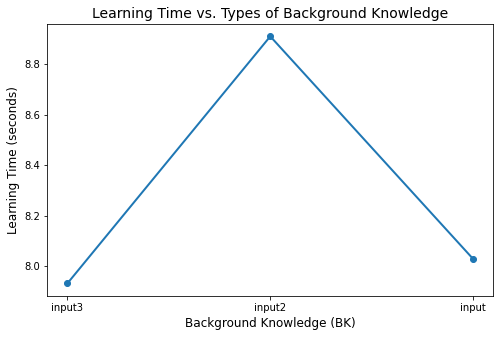

In [3]:
import time
import matplotlib.pyplot as plt
from pyswip import Prolog
import warnings
warnings.filterwarnings("ignore", category=Warning)

def measure_learning_time(input_file):
    """
    Measure the time taken to induce hypotheses using Aleph.
    """
    try:
        prolog = Prolog()

        # Consult the Prolog file
        prolog.consult(input_file)

        # Measure induction time
        start_time = time.time()
        query = "induce(H)"
        result = list(prolog.query(query))
        end_time = time.time()

        learning_time = end_time - start_time
        return learning_time
    except Exception as e:
        print(f"An error occurred: {e}")
        return None

def plot_learning_time_line(results):
    """
    Plot learning time as a line graph for different types of background knowledge.
    """
    bk_types = list(results.keys())
    times = [t if t is not None else 0 for t in results.values()]  # Replace None with 0

    plt.figure(figsize=(8, 5))
    plt.plot(bk_types, times, marker='o', linestyle='-', linewidth=2)
    plt.xlabel('Background Knowledge (BK)', fontsize=12)
    plt.ylabel('Learning Time (seconds)', fontsize=12)
    plt.title('Learning Time vs. Types of Background Knowledge', fontsize=14)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.show()

if __name__ == "__main__":
    # File paths
    base_path = "/user/HS401/lm02027/Downloads/carcinogenesis"
    bk_files = {
        "input3": f"{base_path}/input3.pl",
        "input2": f"{base_path}/input2.pl",
        "input": f"{base_path}/input.pl"
    }

    # Measure and store learning times
    results = {}
    for bk_name, bk_file in bk_files.items():
        print(f"Evaluating BK: {bk_name}")
        learning_time = measure_learning_time(bk_file)
        results[bk_name] = learning_time

    # Plot learning time graph as a line chart
    plot_learning_time_line(results)

# 5-fold Comparison of Algorithms for Dataset 1

SVM: 0.9689 (0.0048)


/user/HS401/lm02027/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/user/HS401/lm02027/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/user/HS401/lm02027/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/user/HS401/lm02027/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/user/HS401/lm02027/

MLP: 0.8004 (0.0011)
Naive Bayes: 0.9563 (0.0049)
Decision Tree: 0.9333 (0.0056)
KNN: 0.9201 (0.0081)


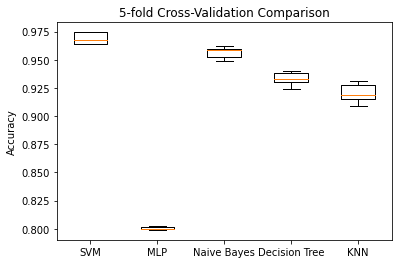

In [5]:
# Referred code from week4 lab
# compare algorithms
# Import necessary libraries
from pandas import read_csv
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd

X = df.iloc[:, 1:-1].values  # All features (excluding first column and target)
y = df.iloc[:, -1].values    # Target variable

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Spot Check Algorithms
models = []
models.append(('SVM', SVC()))
models.append(('MLP', MLPClassifier(random_state=0, activation='logistic', hidden_layer_sizes=(10,), max_iter=100)))
models.append(('Naive Bayes', GaussianNB()))
models.append(('Decision Tree', DecisionTreeClassifier()))
models.append(('KNN', KNeighborsClassifier()))

# Evaluate each model using 10-fold cross-validation
results = []
names = []

for name, model in models:
    # StratifiedKFold ensures balanced class distribution across splits
    kfold = StratifiedKFold(n_splits=5, random_state=1, shuffle=True)
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
    results.append(cv_results)
    names.append(name)
    print(f'{name}: {cv_results.mean():.4f} ({cv_results.std():.4f})')

# Compare Algorithms using boxplot
plt.boxplot(results, labels=names)
plt.title('5-fold Cross-Validation Comparison')
plt.ylabel('Accuracy')
plt.show()

# 5-fold Comparison of Algorithms for Dataset 2

SVM: 0.8853 (0.0024)


/user/HS401/lm02027/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/user/HS401/lm02027/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/user/HS401/lm02027/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/user/HS401/lm02027/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/user/HS401/lm02027/

MLP: 0.9086 (0.0030)
Naive Bayes: 0.7491 (0.0022)
Decision Tree: 0.8974 (0.0010)
KNN: 0.8377 (0.0023)


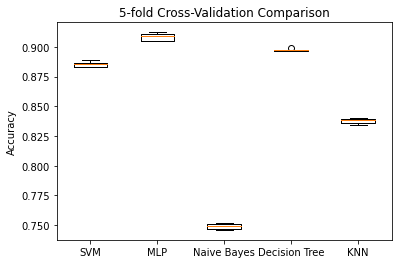

In [7]:
# Referred code from week4 lab
# compare algorithms
# Import necessary libraries
from pandas import read_csv
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd

X = df.drop('loan_status', axis=1)  # 'loan_status' is the target column
y = df['loan_status']
from sklearn.model_selection import train_test_split
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Spot Check Algorithms
models = []
models.append(('SVM', SVC()))
models.append(('MLP', MLPClassifier(random_state=0, activation='logistic', hidden_layer_sizes=(10,), max_iter=100)))
models.append(('Naive Bayes', GaussianNB()))
models.append(('Decision Tree', DecisionTreeClassifier()))
models.append(('KNN', KNeighborsClassifier()))

# Evaluate each model using 10-fold cross-validation
results = []
names = []

for name, model in models:
    # StratifiedKFold ensures balanced class distribution across splits
    kfold = StratifiedKFold(n_splits=5, random_state=1, shuffle=True)
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
    results.append(cv_results)
    names.append(name)
    print(f'{name}: {cv_results.mean():.4f} ({cv_results.std():.4f})')

# Compare Algorithms using boxplot
plt.boxplot(results, labels=names)
plt.title('5-fold Cross-Validation Comparison')
plt.ylabel('Accuracy')
plt.show()